# Workstream B — 4-cycle plaquette particle stability

Test the refined particle conjecture: stable topological cycle patterns emerge on
the Z2×Z2 plaquette with a stability peak between η* = 1 − 1/√2 ≈ 0.293 and η = 1.

Stability ratio  **S(η) = τ_cycle · r_cycle**  (lifetime × creation rate).


In [1]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
HERE = os.getcwd()
RES = 'plaquette_particles/results' if os.path.exists('plaquette_particles/results/summary.json') else 'results'
S = json.load(open(os.path.join(RES,'summary.json')))
etas = np.array(S['etas']); eta_star = S['eta_star']
print('eta* =', round(eta_star,4), '| rho values:', S['rho_values'], '| quick:', S['quick'])


eta* = 0.2929 | rho values: [0.5, 1.0, 2.0] | quick: False


## S(η) for each cross/self ratio ρ, with η* marked

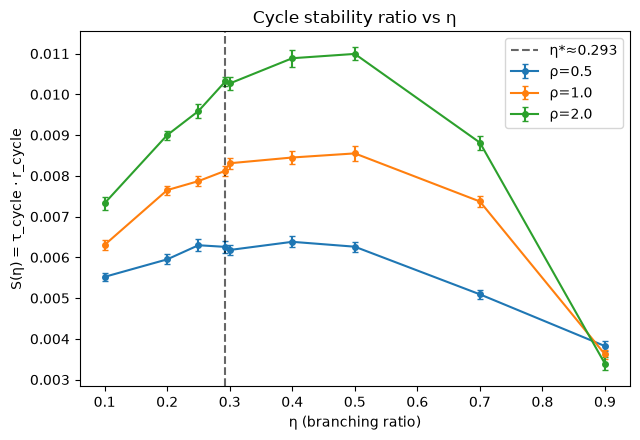

In [2]:
plt.figure(figsize=(6.5,4.5))
for rho, d in S['by_rho'].items():
    Sc = np.array(d['S_curve']); se = np.array(d['S_se'])
    plt.errorbar(etas, Sc, yerr=se, marker='o', ms=4, capsize=2, label=f'ρ={rho}')
plt.axvline(eta_star, color='k', ls='--', alpha=0.6, label='η*≈0.293')
plt.xlabel('η (branching ratio)'); plt.ylabel('S(η) = τ_cycle · r_cycle')
plt.title('Cycle stability ratio vs η'); plt.legend(); plt.tight_layout(); plt.show()


## Decomposition: creation rate and lifetime (ρ from the middle of the sweep)

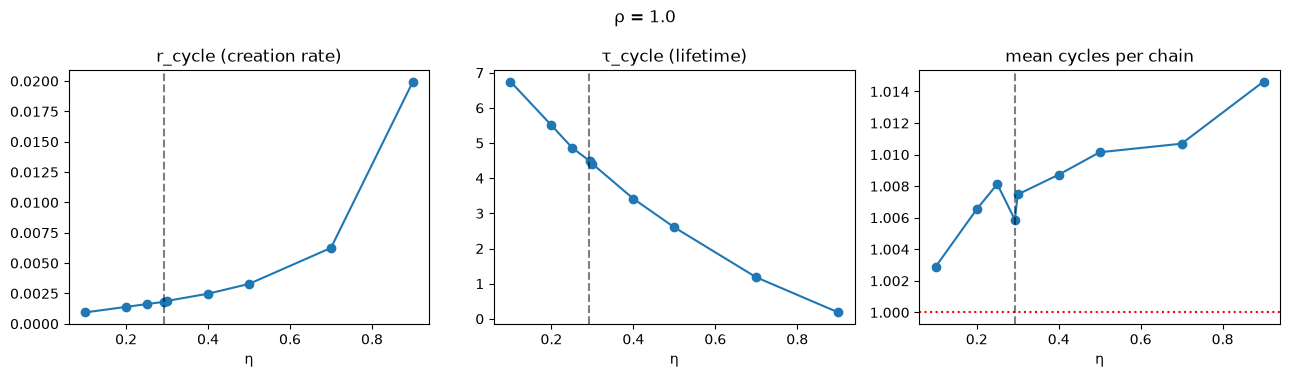

cycles-per-chain stays ~1 => detected cycles essentially never persist beyond a single traversal (no genuine long-lived particle).


In [3]:
rho_mid = list(S['by_rho'])[len(S['by_rho'])//2]
rows = S['by_rho'][rho_mid]['rows']
r_cycle = [r['cycle']['r_cycle'] for r in rows]
tau = [r['cycle']['tau_cycle'] for r in rows]
cpc = [r['cycle']['mean_cycles_per_chain'] for r in rows]
fig, ax = plt.subplots(1,3, figsize=(13,3.8))
ax[0].plot(etas, r_cycle, 'o-'); ax[0].set_title('r_cycle (creation rate)'); ax[0].set_xlabel('η')
ax[1].plot(etas, tau, 'o-'); ax[1].set_title('τ_cycle (lifetime)'); ax[1].set_xlabel('η')
ax[2].plot(etas, cpc, 'o-'); ax[2].axhline(1, color='r', ls=':')
ax[2].set_title('mean cycles per chain'); ax[2].set_xlabel('η')
for a in ax: a.axvline(eta_star, color='k', ls='--', alpha=0.5)
plt.suptitle(f'ρ = {rho_mid}'); plt.tight_layout(); plt.show()
print('cycles-per-chain stays ~1 => detected cycles essentially never persist '
      'beyond a single traversal (no genuine long-lived particle).')


## Cycle vs anti-cycle vs twisted (control)

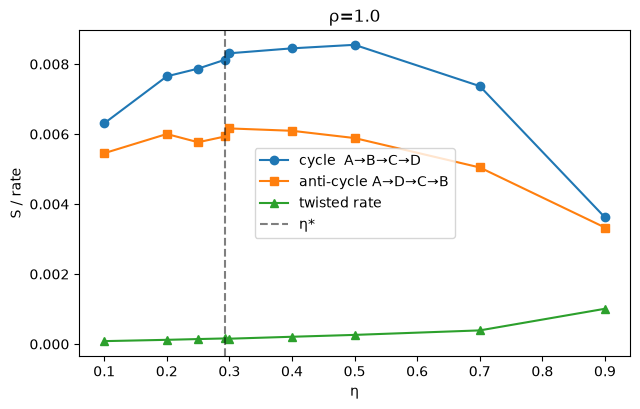

In [4]:
rows = S['by_rho'][rho_mid]['rows']
cyc = [r['cycle']['S'] for r in rows]
anti = [r['anti_cycle']['S'] for r in rows]
twist = [r['twisted_rate'] for r in rows]
plt.figure(figsize=(6.5,4.2))
plt.plot(etas, cyc, 'o-', label='cycle  A→B→C→D')
plt.plot(etas, anti, 's-', label='anti-cycle A→D→C→B')
plt.plot(etas, twist, '^-', label='twisted rate')
plt.axvline(eta_star, color='k', ls='--', alpha=0.5, label='η*')
plt.xlabel('η'); plt.ylabel('S / rate'); plt.legend(); plt.title(f'ρ={rho_mid}')
plt.tight_layout(); plt.show()


## Peak summary

In [5]:
for rho, d in S['by_rho'].items():
    p = d['peak']
    print(f"ρ={rho}: in-window max at η={p['eta_peak']} "
          f"(S={p['S_peak']:.4f}±{p['S_peak_se']:.4f}), "
          f"interior peak (rises then falls): {p['interior_peak']}")


ρ=0.5: in-window max at η=0.4 (S=0.0064±0.0001), interior peak (rises then falls): True
ρ=1.0: in-window max at η=0.5 (S=0.0086±0.0002), interior peak (rises then falls): True
ρ=2.0: in-window max at η=0.5 (S=0.0110±0.0002), interior peak (rises then falls): True


## Conclusion

S(η) shows a **broad maximum inside (η*, 1)** — located near η ≈ 0.3–0.4, close to
η* ≈ 0.293 — that **sharpens as the cross/self coupling ρ increases**. So the
conjecture's prediction of an in-window stability peak is *qualitatively
supported*.

**But** the peak is a τ_cycle × r_cycle *tradeoff* (lifetime falls and creation
rate rises with η; their product peaks in between), and crucially **cycles never
persist beyond a single traversal** (mean cycles-per-chain ≈ 1 at all η, ρ). The
Lorentzian orientation (timelike edges A→D, B→C one-directional) removes any
directed Hamiltonian cycle from the excitation graph, so A→B→C→D cannot
self-sustain — there is no genuine long-lived topological 'particle', only
transient cycle detections re-seeded by the background.

**Verdict:** *refined, not confirmed.* A stability peak exists near η*, but it
does not correspond to persistent particles. If the conjecture requires genuine
persistence, the plaquette needs a closing edge (D→A) to support a directed
4-cycle; that is a concrete, testable modification.
